# Session 5: Supervised Learning – Classification (Tree-Based Models)

**Session Objective:** Recap decision trees; implement and compare tree-based classifiers (Decision Tree, Random Forest, Gradient Boosting) in scikit-learn. Apply cross-validation and GridSearchCV to tune model hyperparameters. Students will train models on real data (e.g. FinScope, Adult, or Soil Quality), compute metrics (accuracy, confusion matrix, precision, recall), and interpret results (true/false positives/negatives). We will also compare models and select the best one using cross-validation to avoid overfitting.

## 🌳 Decision Tree (Classification) (40 minutes)

**Recap (from Session 4 EDA):** In the previous session, you analyzed data distributions and relationships to understand features like income or age. Now, decision trees use these features to make decisions.

Recall what you learned in AI Wizards about decision tree. You also performed decision tree by Hand. Here is a quick example of how decision tree is used in real life scenario. 
- Imagine in deciding whether to approve a loan. A decision tree can be used to asks a series of yes/no questions (e.g. “Is credit score > threshold?”, “Is income above X?”). Each question splits the data, which into approve or not. This mirrors how decision trees work: a tree-like structure of decisions leads to a final classification. In banking, decision trees are often used for loan approvals.

*NOTE*: The model architecture of this machine learning model and the other follwing in the next sesions wont be discused in details as they already covered in **AI Wizards** sessions. Here the focus will be on how to build these model using **Python** with **Scikitlearn** Machine learning library. 

<details>
<summary> What are the key terminologies used in decision tree model?</summary>

A decision tree partitions data by asking questions on feature values. It starts at a root node and splits on the best feature (using criteria like Gini impurity or entropy) to reduce uncertainty. Splitting continues until leaf nodes (which make final predictions). Key points:
* **Splitting criteria:** Gini impurity or entropy measures how mixed classes are in a node; the tree chooses splits that reduce these measures the most.
* **Max depth:** Controls tree complexity. A very deep tree may perfectly fit training data but overfit (memorize noise), leading to poor generalization.
* **Pruning:** Techniques like limiting depth or removing weak branches help prevent overfitting.
</details>

<details>
<summary>What are advantages and disadvantages of decision tree?</summary>

* **Advantages:** Easy to interpret, no need to scale features, handles non-linear patterns.
* **Disadvantages:** Prone to overfitting if not controlled.
</details>


### **Decision Tree with Python**

To build a classification decision tree with Python, you primarily use the `DecisionTreeClassifier` of **Scikitlearn** machine learning library.
The `DecisionTreeClassifier`: is a powerful, non-parametric supervised learning method used for classification tasks. It asks a series of yes/no questions about the data features until it reaches a conclusion (the class label).

<details>
<summary> What are the key parameter for building Decision tree?</summary>

Key Parameters of `DecisionTreeClassifier`
- In `scikit-learn`, these parameters are "knobs and dials" to control how the tree grows and, more importantly, how to stop it from growing too much (overfitting).
   1. ***Splitting Quality***:
        - `criterion` (Default: 'gini'): This is the mathematical function used to measure the quality of a split.
            - **'gini'**: Measures "Gini Impurity." It calculates the probability of a specific variable being wrongly classified when chosen randomly.

            - **'entropy'**: Measures "Information Gain." It uses the logarithmic measure of uncertainty.
         
        - `splitter` (Default: 'best'): How the tree chooses the split at each node. 'best' looks for the most informative split, while 'random' picks the best among a random subset, which can help reduce overfitting.

    2. ***Growth Control (Pruning)***: These are essential to prevent the tree from memorizing training data (overfitting).
        - `max_depth`: The maximum number of levels in the tree. If left as None, the tree grows until all leaves are pure. Start small (3–5) and increase only if needed.
        
        - `min_samples_split`: The minimum number of samples a node must have before it can be split. High values prevent the tree from making decisions based on tiny groups of data.
        
        - `min_samples_leaf`: The minimum number of samples required to be at a leaf node. This "smooths" the model by ensuring no leaf is based on an outlier.
    3. ***Complexity & Features***:
        - `max_features`: The number of features to consider when looking for the best split. You can pass an integer, a float (percentage), or strings like 'sqrt' or 'log2'.
        
        - `random_state`: Used to ensure results are reproducible. Since there is some randomness in how splits are evaluated (especially if features have equal importance), setting this to a fixed number (like 42) ensures you get the same tree every time you run the code.
        
        - `ccp_alpha`: Used for Minimal Cost-Complexity Pruning. A larger alpha increases the amount of pruning, resulting in smaller trees.

    <details>
    <summary>
    *Summary Table*: Common Parameters
    </summary>
       |Parameter|Type|Default|Use Case|
       |---------|----|-------|--------|
       |max_depth|int|None|Primary way to stop overfitting.|
       |criterion|str|'gini'|Use 'entropy' for more balanced trees.|
       |min_samples_leaf|int|1|Increase to ignore noise in the data.|
       |class_weight|dict/str|None|Use 'balanced' if one class is much rarer than others.|
    </details>
</details>

We will load a dataset (e.g. FinScope or a standard UCI dataset), split into training and test sets, and train a DecisionTreeClassifier. Then we compute accuracy, confusion matrix, precision and recall. We’ll also visualize the tree structure (e.g. using plot_tree) and inspect feature importances.

### 🛠️ **The Implementation Flow**

1. **Import Libraries and Data**
First, load the model, the data, and some evaluation tools.
- *Scikit-learn* act as toolbox, you need to know what to tool you need to accomplish a certain task. *Python* act as an employee, after the task have been assigned to employee, employee need to know where to look for a tool to accomplish the task assigned to him. 

- `from sklearn.tree import DecisionTreeClassifier, plot_tree` this is Python language, in English langue the line mean: Go to the `sklearn` toolbox at location called `tree` take the two tools the `DecisionTreeClassifier` and the `plot_tree`. This means the 'plot_tree' and 'DecisionTreeClassifier' both are located inside 'tree' setion of 'sklearn' toolbox. 

- Now lets collect all the tools need for Decision tree task from sklearn toolbox.

In [ ]:
# Install scikit-learn if you haven't already
# !pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 3.4 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.1 MB 4.0 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.1 MB 3.7 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 3.6 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 3.5 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 3.3 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.1 MB 3.2 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.1 MB 3.2 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 3.2 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 3.2 MB/s eta 0:00:01
   ----------------------------------- 

In [ ]:
## Import necessary libraries

# Import the Decision Tree Classifier and plotting function
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Import evaluation metrics tools
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Import train_test_split for splitting the dataset
from sklearn.model_selection import train_test_split

# Import pandas for data manipulation and matplotlib for plotting
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
## Load the dataset

# Load the Soil_quality dataset from Data folder
data = pd.read_csv('../Data/FinScope_cleaned.csv')

data.head()

,Income_source,Savings_habits,Borrowing_status,Financial_education,Age,Gender,Marital_status,Educational_level,Geographic_location,NIDA_number,Smartphone_ownership,has_bank_account
0,farmers and fishers,no,yes,False,47,female,marriedliving together,some primary,rural,no,no,one account
1,farmers and fishers,yes,no,False,63,female,widowed,no formal education,rural,no,no,one account
2,piece workcasual labor,yes,yes,True,74,male,widowed,some primary,other urban,yes,no,one account
3,traders nonagricultural,yes,yes,False,29,female,divorcedseparated,some primary,other urban,no,no,one account
4,farmers and fishers,yes,yes,False,53,male,marriedliving together,primary completed,dar es salaam,yes,no,one account


In [10]:
# Check unique values in the target variable
print(data['has_bank_account'].value_counts())

has_bank_account
one account                 9671
two or three accounts        234
more than three accounts      10
Name: count, dtype: int64


In [11]:
# Categorical encoding for 'has_banka_account'
data['has_bank_account_encoded'] = data['has_bank_account'].map({'one account': 0, 'two or three accounts': 1, 'more than three accounts': 1})
data.head()

,Income_source,Savings_habits,Borrowing_status,Financial_education,Age,Gender,Marital_status,Educational_level,Geographic_location,NIDA_number,Smartphone_ownership,has_bank_account,has_bank_account_encoded
0,farmers and fishers,no,yes,False,47,female,marriedliving together,some primary,rural,no,no,one account,0
1,farmers and fishers,yes,no,False,63,female,widowed,no formal education,rural,no,no,one account,0
2,piece workcasual labor,yes,yes,True,74,male,widowed,some primary,other urban,yes,no,one account,0
3,traders nonagricultural,yes,yes,False,29,female,divorcedseparated,some primary,other urban,no,no,one account,0
4,farmers and fishers,yes,yes,False,53,male,marriedliving together,primary completed,dar es salaam,yes,no,one account,0


In [12]:
# Drop the 'has_bank_account' column as we now have the encoded version
data.drop('has_bank_account', axis=1, inplace=True)

In [13]:
data.head()

,Income_source,Savings_habits,Borrowing_status,Financial_education,Age,Gender,Marital_status,Educational_level,Geographic_location,NIDA_number,Smartphone_ownership,has_bank_account_encoded
0,farmers and fishers,no,yes,False,47,female,marriedliving together,some primary,rural,no,no,0
1,farmers and fishers,yes,no,False,63,female,widowed,no formal education,rural,no,no,0
2,piece workcasual labor,yes,yes,True,74,male,widowed,some primary,other urban,yes,no,0
3,traders nonagricultural,yes,yes,False,29,female,divorcedseparated,some primary,other urban,no,no,0
4,farmers and fishers,yes,yes,False,53,male,marriedliving together,primary completed,dar es salaam,yes,no,0


2. **Split the Data**
- We never test on the same data we used for training—that’s like giving a student the exact questions that will be on the final exam.

In [ ]:
# Ecode all categorical variables using one-hot encoding
data = pd.get_dummies(data, drop_first=True)
data.head()


,Financial_education,Age,has_bank_account_encoded,Income_source_farmers and fishers,Income_source_formal sector salaried,Income_source_gambling,Income_source_informal sector salaried,Income_source_interest from savings investments stocks unit trusts etc,Income_source_other,Income_source_pension,...,Educational_level_secondary completeda level,Educational_level_some primary,Educational_level_some secondary,Educational_level_some university or other higher education,Educational_level_university or higher education completed,Geographic_location_other urban,Geographic_location_rural,Geographic_location_zanzibar,NIDA_number_yes,Smartphone_ownership_yes
0,False,47,0,True,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
1,False,63,0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,True,74,0,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
3,False,29,0,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
4,False,53,0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [18]:
# Split the dataset into features and target variable
X = data.drop('has_bank_account_encoded', axis=1)
y = data['has_bank_account_encoded']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

3. **Train the Model**
This is where the "learning" happens. The tree looks at the features and finds the best way to split the data to separate the classes.
  - Use `.fit()` to fit the model with the data
  - use `.predict()` to predict the output based on fitted model

In [19]:
# Train decision tree

tree = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

4. **Evaluate the Results**

Now we see how well it performs on unseen data.

In [20]:
# Evaluation

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'Accuracy: {acc:.2f}')
print('Confusion Matrix:\n', cm)
print(f'Precision: {precision:.2f}, Recall: {recall:.2f}')


Accuracy: 0.98
Confusion Matrix:
 [[1933    1]
 [  48    1]]
Precision: 0.50, Recall: 0.02


🌳 **Visualizing the Logic**

One of the coolest features of scikit-learn is plot_tree. It allows you to see exactly which features (like petal length or width) the model used to make its decisions.

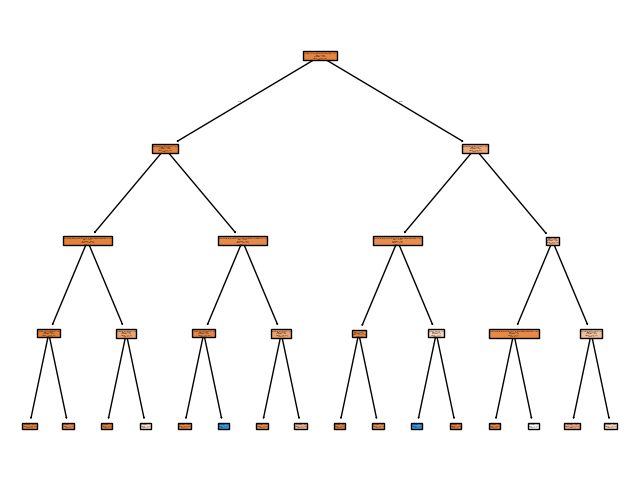

In [21]:
# Visualize tree
plt.figure(figsize=(8,6))
plot_tree(tree, feature_names=X.columns, class_names=['0','1'], filled=True)
plt.show()

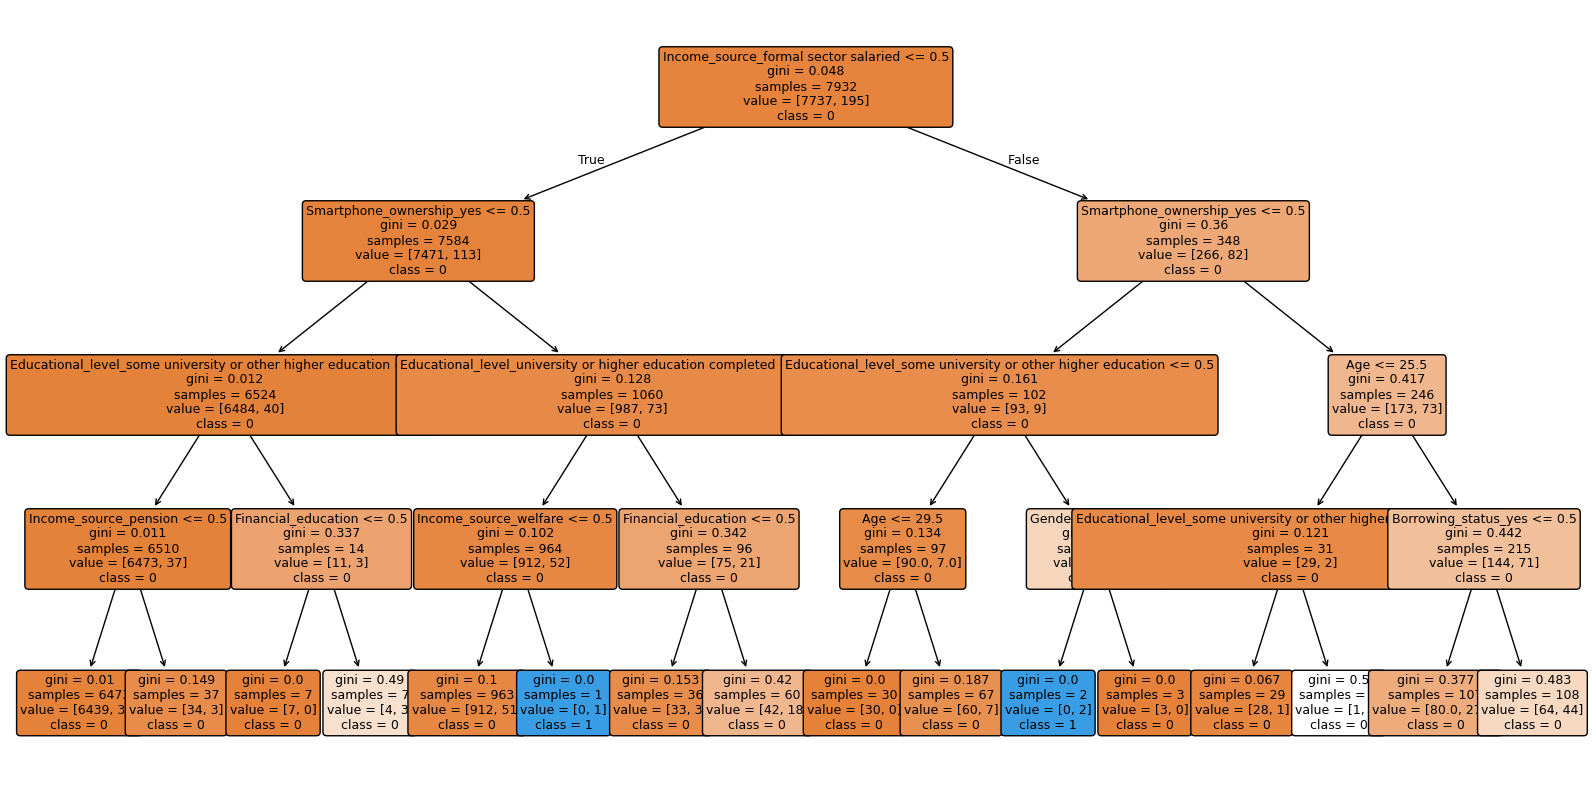

In [24]:
plt.figure(figsize=(20,10)) # 1. Increase the figure size!
plot_tree(
    tree, 
    feature_names=X.columns,    # 2. Shows 'Income' instead of 'X[0]'
    class_names=['0', '1'],     # 3. Shows the target labels
    filled=True,                # 4. Colors the nodes by class
    rounded=True,               # 5. Makes it look cleaner
    fontsize=9                 # 6. Makes the text readable
)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

# Example with a sample dataset (replace with actual FinScope/Adult data)
# data = pd.read_csv('data.csv')
# X = data.drop('target', axis=1)
# y = data['target']
# X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

print("Ensure your data is loaded and split before running the classifier.")

# Train decision tree
# tree = DecisionTreeClassifier(max_depth=4, random_state=42)
# tree.fit(X_train, y_train)
# y_pred = tree.predict(X_test)

# Evaluation
# acc = accuracy_score(y_test, y_pred)
# cm = confusion_matrix(y_test, y_pred)
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)
# print(f'Accuracy: {acc:.2f}')
# print('Confusion Matrix:\n', cm)
# print(f'Precision: {precision:.2f}, Recall: {recall:.2f}')

# Visualize tree
# plt.figure(figsize=(8,6))
# plot_tree(tree, feature_names=X.columns, class_names=['0','1'], filled=True)
# plt.show()

**Practice Task:**
1. Build a DecisionTreeClassifier on the Adult data dataset. Experiment with parameters like max_depth or criterion.
2. Interpret the tree: which features are at the top splits? What do the leaf decisions mean?
3. Compute evaluation metrics and identify true/false positives/negatives.

**Hint:** Use DecisionTreeClassifier from scikit-learn and functions like accuracy_score, confusion_matrix, precision_score, and recall_score. Compare training vs test accuracy to spot overfitting.

## 🌲 Random Forest Ensemble (30 minutes)

**Recap:** A single decision tree can overfit. To improve stability, we use ensembles. Random Forest is an ensemble of many decision trees, each trained on a random subset of data and features. It aggregates their votes to make a prediction. This reduces variance and overfitting.

**Scenario:** Continuing the loan approval example, instead of relying on one banker’s decision tree, a microfinance officer consults many independent experts (trees), each seeing slightly different data (bagging). The final decision is by majority vote. This ensemble approach yields more accurate, robust results.



**Technical:** A Random Forest uses bagging (bootstrap aggregation): it trains each tree on a random sample of data (with replacement) and often on a random subset of features. Key points:
* Each tree is deep (unpruned), but because of averaging, the model’s overall variance is much lower than a single tree.
* Reduces overfitting: random forests typically generalize better than a single tree.
* Feature randomness (each split considers only a subset of features) decorrelates trees.
* We can extract feature importances from a random forest to see which features most influence predictions.

**Code Demo (RandomForestClassifier):** We will train RandomForestClassifier on the same data, tune number of trees (n_estimators), and compute metrics. We will display feature importances to interpret the model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

# Train random forest
# rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
# rf.fit(X_train, y_train)
# y_pred_rf = rf.predict(X_test)

# Evaluation
# acc_rf = accuracy_score(y_test, y_pred_rf)
# cm_rf = confusion_matrix(y_test, y_pred_rf)
# precision_rf = precision_score(y_test, y_pred_rf)
# recall_rf = recall_score(y_test, y_pred_rf)
# print(f'Random Forest Accuracy: {acc_rf:.2f}')

# Feature importances
# importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
# print("Feature importances:\n", importances)

# Plot feature importances
# plt.figure(figsize=(6,4))
# sns.barplot(x=importances.values, y=importances.index)
# plt.title('Feature Importances (Random Forest)')
# plt.show()

**Practice Task:**
1. Train a RandomForestClassifier on the data. Try different n_estimators and max_depth.
2. Compare its performance (accuracy, precision, recall) to the decision tree.
3. Identify the most important features. How do they align with domain knowledge?
4. Discuss variance reduction: does the random forest overfit less than the single tree?

## ⚡ Gradient Boosting (GradientBoostingClassifier) (30 minutes)

**Recap:** We have learned bagging (Random Forest) to reduce variance. Boosting is another ensemble strategy that reduces bias by sequentially training trees.

**Scenario:** Suppose we entered a data science competition to predict credit default. We first build a simple model. Boosting allows us to iteratively improve predictions: after each tree, we focus on the mistakes of the previous models, gradually correcting errors. For example, the first tree might predict most cases correctly but miss some frauds. The next tree then tries hard on those misclassified cases, improving overall accuracy.



**Technical:** Gradient Boosting Machines (GBM) build trees one at a time; each new tree fits the residuals (errors) of the combined previous ensemble. Key points:
* It minimizes a loss function (e.g., log-loss for classification) via gradient descent, adding trees to improve performance.
* Main hyperparameters: n_estimators (number of trees), learning_rate (how much each tree contributes), max_depth (depth of each tree).
* Lower learning rate with more trees often improves performance but increases computation.
* Powerful but can overfit if too many trees or too deep. Early stopping or tuning can prevent this.

**Code Demo (GradientBoostingClassifier):** We will train GradientBoostingClassifier, tune n_estimators, learning_rate, and compare performance to previous models.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Train gradient boosting
# gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
# gb.fit(X_train, y_train)
# y_pred_gb = gb.predict(X_test)

# Evaluation
# acc_gb = accuracy_score(y_test, y_pred_gb)
# cm_gb = confusion_matrix(y_test, y_pred_gb)
# precision_gb = precision_score(y_test, y_pred_gb)
# recall_gb = recall_score(y_test, y_pred_gb)
# print(f'Gradient Boosting Accuracy: {acc_gb:.2f}')

**Practice Task:**
1. Fit a GradientBoostingClassifier. Experiment with n_estimators and learning_rate (e.g. try learning rates 0.01, 0.1, 0.2).
2. Use a validation set or cross_val_score to assess accuracy for each setting.
3. Compare this model’s metrics to the random forest and single tree. Which performs best on validation?
4. Watch out for overfitting: does training accuracy become much higher than test accuracy when trees are too many?

## 🔄 Cross-Validation & Hyperparameter Tuning (45 minutes)

**Recap:** So far, we split data into a single train/test set. To get a reliable estimate of model performance, we use k-fold cross-validation. This helps avoid overfitting by testing the model on multiple splits.

**Scenario:** Before trusting our credit model, we want to ensure it will generalize. In cross-validation, we imagine repeatedly running our model on different train/test splits. For instance, in 5-fold CV, the data is split into 5 parts; each part is test once, while the other 4 train the model. We average results to get a more reliable accuracy.



**Technical:**
* **K-Fold CV:** Splits data into k equal folds. Train on k–1 folds, test on 1, and repeat so each fold is used as test once. Gives a distribution of performance; average is a robust estimate.
* **Why important:** K-Fold CV reduces variance in performance estimation and is a better gauge than a single split.
* **Hyperparameter Tuning:** We can tune model hyperparameters using GridSearchCV (an exhaustive search) with cross-validation. GridSearchCV tries all combinations of specified parameters and selects the best based on CV score.
* **Parameters to tune:** for trees – e.g. max_depth, n_estimators, learning_rate. For random forest – n_estimators, max_depth, max_features.

**Code Demo (cross_val_score and GridSearchCV):** We will use cross_val_score to compare models and GridSearchCV to find optimal hyperparameters.

In [ ]:
from sklearn.model_selection import cross_val_score, GridSearchCV

# Cross-validation scores for each model
# for model, name in [(tree, "Decision Tree"), (rf, "Random Forest"), (gb, "Gradient Boosting")]:
#     scores = cross_val_score(model, X, y, cv=5)
#     print(f"{name} CV accuracy: {scores.mean():.2f} ± {scores.std():.2f}")

# Example GridSearch for Random Forest
# param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}
# grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
# grid_rf.fit(X_train, y_train)
# print("Best RF params:", grid_rf.best_params_)
# print("Best RF CV score:", grid_rf.best_score_)

# Example GridSearch for Gradient Boosting
# param_grid = {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1], 'max_depth': [3,5]}
# grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
# grid_gb.fit(X_train, y_train)
# print("Best GB params:", grid_gb.best_params_)

**Practice Task:**
1. Use cross_val_score on your chosen model(s) to compute 5-fold cross-validated accuracy.
2. Perform a grid search: for example, tune n_estimators and max_depth for random forest, or learning_rate and n_estimators for boosting.
3. Record the best parameters found and the corresponding CV score.
4. Discuss how tuning affects performance and overfitting (e.g. does a deeper tree always help?).

## 🛠️ Mini Project: Build and Compare Tree Models (20 minutes)

**Scenario:** Using one of the datasets (e.g. Tanzania FinScope “has_bank_account” or Adult income), apply everything learned. Guide yourself through these steps:

**Data Preparation:**
* Load the dataset and split into features X and binary target y.
* Perform train-test split (e.g. 70% train, 30% test) with a fixed random seed.

**Train Models:**
* Train a DecisionTreeClassifier, RandomForestClassifier, and GradientBoostingClassifier on the training set (use default or simple parameters).
* Predict on the test set for each model.

**Evaluate Performance:**
* Compute accuracy, confusion matrix, precision, and recall for each model.
* Summarize results in a table for easy comparison.

**Interpretation:**
* Identify which model has the highest accuracy.
* Compare confusion matrices: which model has fewer false positives or false negatives?
* Extract feature importances from the random forest: which features matter most?

**Cross-Validation Check:**
* Use cross_val_score (5-fold) to estimate each model’s accuracy. Are the CV scores consistent with the single test accuracy?
* Discuss any differences.

**Hyperparameter Tuning:**
* Run a brief grid search (even with just a few settings) on one or two models to see if performance improves.
* Report the best parameters and any gain in accuracy.

Throughout the mini project, write Markdown notes summarizing each step and your observations. This guided exercise consolidates your skills in building, tuning, and interpreting tree-based models on real data.

## 🚀 Capstone Project: Tasks and Deliverables (25 minutes)

For the capstone project, learners will apply tree-based classification on a real-world problem and synthesize their findings. The tasks are:

**Dataset:** Choose one of the provided binary classification datasets (e.g., FinScope “has_bank_account”, UCI Adult income, or Soil quality).

**Tasks:**
1. **Data Loading and Cleaning:** Load the dataset, handle missing values or encoding as needed.
2. **Data Splitting:** Split into train and test sets (e.g. 80/20).
3. **Baseline Model (Decision Tree):** Train a DecisionTreeClassifier. Compute accuracy, confusion matrix, precision, and recall. Analyze errors (inspect false positives/negatives).
4. **Random Forest & Gradient Boosting:** Train RandomForestClassifier and GradientBoostingClassifier. Again compute evaluation metrics for each.
5. **Cross-Validation:** For each model, perform 5-fold cross-validation (use cross_val_score) and report average accuracy ± std.
6. **Hyperparameter Tuning:** Use GridSearchCV to tune key parameters for at least two models (e.g. depth and estimators for RF, learning rate for GBM). Note the best parameters and cross-validated score.
7. **Model Comparison:** Compare the models on the test set (and CV scores). Which model performs best? Consider both accuracy and overfitting risk.
8. **Write-Up:** Summarize your findings in a brief report. Discuss trade-offs observed, such as computation time vs. accuracy, and how tree depth or number of trees affected performance. Justify the final model choice.

**Deliverable:** A Jupyter notebook containing all code, results (with output) and answers to the tasks above, plus a short written summary of conclusions. Include plots (e.g. confusion matrices, feature importance bar charts) as needed to support your analysis.

By completing these tasks, learners will demonstrate mastery of tree-based classifiers, evaluation metrics, cross-validation, and hyperparameter tuning on a practical problem.